# EMF Curves of Freezing Lead–Acid Batteries

Example EMF-Time curves of lead–acid batteries when freezing the electrolyte at low temperatures.


In [214]:
import os
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.figure import Figure
from matplotlib.axes import Axes
from matplotlib.ticker import FuncFormatter

In [215]:
import importlib
import matplotlib

importlib.reload(matplotlib)
plt.rcdefaults()

In [216]:
DATA_DIRECTORY = "../Data/Freezing"

## Data Import

In [217]:
# There are 4 files for 2 batteries for both the freezing and thawing processes named as:
# "SISPS-EXP-SOH EMF-TIME-{FR/TH}-{C13/C14}.csv"

FILE_NAMES = [f for f in os.listdir(DATA_DIRECTORY) if f.endswith(".csv")]

emf_data = {}
for file_name in FILE_NAMES:
    file_path = os.path.join(DATA_DIRECTORY, file_name)
    df = pd.read_csv(
        file_path,
        skiprows=23,
        # Each line ends with a comma, ignore the last empty column
        usecols=lambda x: x not in ["Unnamed: 3"],
    )

    battery_id = file_name.split("-")[-1].split(".")[
        0
    ]  # Extract battery ID from the file name
    freeze_thaw = file_name.split("-")[-2]  # Extract freeze/thaw from the file name

    if battery_id not in emf_data:
        emf_data[battery_id] = {}

    emf_data[battery_id][freeze_thaw] = df

print(
    emf_data["C13"]["FR"].head()
)  # Print the first few rows of the freezing data for battery C13

               Time Stamp(s)  Records  DC Voltage (VDC)
0  2026-09-7 13:16:48.359553        1         11.171531
1  2026-09-7 13:17:18.350626        2         11.171567
2  2026-09-7 13:17:48.359715        3         11.171578
3  2026-09-7 13:18:18.418248        4         11.171586
4  2026-09-7 13:18:48.377318        5         11.171563


In [218]:
emf_data["C13"]["TH"].keys()

Index(['Time Stamp(s)', 'Records', 'DC Voltage (VDC)'], dtype='str')

In [219]:
def add_time_from_timestamps(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add a new column 'Time' to the DataFrame, representing the time in seconds
    since the start of the experiment based on the 'Timestamp' column.
    """
    timestamps = pd.to_datetime(df["Time Stamp(s)"])
    df["Time"] = timestamps - timestamps.iloc[0]
    return df


_ = [
    add_time_from_timestamps(emf_data[battery_id][freeze_thaw])
    for battery_id in emf_data
    for freeze_thaw in emf_data[battery_id]
]

In [220]:
def plot_emf_curve(
    emf_data,
    battery_id,
    thawing_period_minutes: int | None = None,  # Default thawing period is 60 minutes
    freezing_period_minutes: int | None = None,  # Default freezing period is 60 minutes
) -> Figure:
    """
    Plot the EMF Freezing and Thawing curves for a given battery ID.
    First plots the thawing curve, breaks the x-axis, and then plots the freezing curve.
    """

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(10, 6),
        sharey=True,
    )

    thawing_data = emf_data[battery_id]["TH"]
    freezing_data = emf_data[battery_id]["FR"]

    if thawing_period_minutes is not None:
        thawing_period_mask = (
            thawing_data["Time"].dt.total_seconds() <= thawing_period_minutes * 60
        )
        thawing_width = thawing_period_minutes
    else:
        thawing_period_mask = np.ones(
            len(thawing_data), dtype=bool
        )  # No mask, include all data
        thawing_width = thawing_data["Time"].dt.total_seconds().max() / 60

    if freezing_period_minutes is not None:
        freezing_period_mask = (
            freezing_data["Time"].dt.total_seconds() <= freezing_period_minutes * 60
        )
        freezing_width = freezing_period_minutes
    else:
        freezing_period_mask = np.ones(
            len(freezing_data), dtype=bool
        )  # No mask, include all data
        freezing_width = freezing_data["Time"].dt.total_seconds().max() / 60

    # Change the subplot widths based on the data range
    total_width = thawing_width + freezing_width
    thawing_ratio = thawing_width / total_width
    freezing_ratio = freezing_width / total_width
    fig.subplots_adjust(left=0.1, right=0.9, wspace=0.02)
    ax[0].set_position([0.1, 0.1, thawing_ratio * 0.8, 0.8])
    ax[1].set_position(
        [0.1 + thawing_ratio * 0.8 + 0.02, 0.1, freezing_ratio * 0.8, 0.8]
    )

    ax[0].plot(
        thawing_data.loc[thawing_period_mask, "Time"].dt.total_seconds() / 60,
        thawing_data.loc[thawing_period_mask, "DC Voltage (VDC)"] / 6,
        label="Thawing",
        color="black",
    )

    ax[1].plot(
        freezing_data.loc[freezing_period_mask, "Time"].dt.total_seconds() / 60,
        freezing_data.loc[freezing_period_mask, "DC Voltage (VDC)"] / 6,
        label="Freezing",
        color="black",
    )

    # Add splines
    ax[0].spines.right.set_visible(False)
    ax[1].spines.left.set_visible(False)
    ax[1].yaxis.tick_right()

    d = 1  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(
        marker=[(-1, -d), (1, d)],
        markersize=12,
        linestyle="none",
        color="k",
        mec="k",
        mew=1,
        clip_on=False,
    )
    ax[0].plot([1, 1], [1, 0], transform=ax[0].transAxes, **kwargs)
    ax[1].plot([0, 0], [0, 1], transform=ax[1].transAxes, **kwargs)

    # Format time as hh:mm
    for axis in ax:
        axis.xaxis.set_major_formatter(
            FuncFormatter(lambda x, _: f"{int(x // 60):02d}:{int(x % 60):02d}")
        )
        axis.grid(
            # Horizontal only grid lines
            which="major",
            axis="y",
            linestyle="--",
            linewidth=0.5,
        )

    # Adjust width of subplots to match the data range
    ax[0].set_xlim(
        0, thawing_data.loc[thawing_period_mask, "Time"].dt.total_seconds().max() / 60
    )
    ax[1].set_xlim(
        0, freezing_data.loc[freezing_period_mask, "Time"].dt.total_seconds().max() / 60
    )

    # Delete the last tick label on the first axis
    ax[0].set_xticks(ax[0].get_xticks()[:-1])
    # Only show x ticks above zero
    ax[0].set_xticks([x for x in ax[0].get_xticks() if x >= 0])

    ax[0].set_title("Thawing Curve")
    ax[1].set_title("Freezing Curve")

    ax[0].set_xlabel("Time (hh:mm)")
    ax[1].set_xlabel("Time (hh:mm)")
    ax[0].set_ylabel("EMF (V)")

    return fig

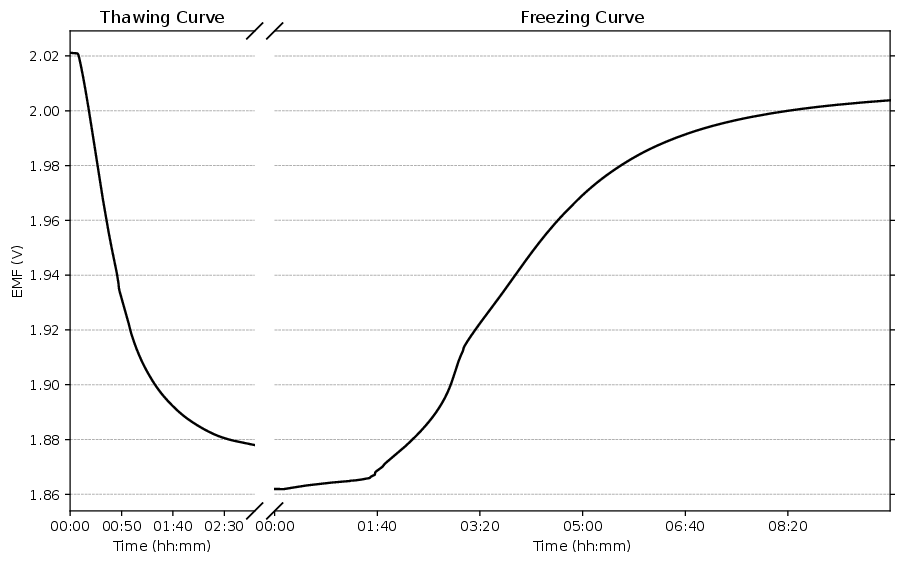

In [221]:
plot_emf_curve(
    emf_data,
    "C13",
    thawing_period_minutes=60 * 3,
    freezing_period_minutes=60 * 10,
)

## PGF Export

In [222]:
import matplotlib

importlib.reload(matplotlib)

plt.rcdefaults()

matplotlib.use("pgf")

plt.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "text.usetex": True,
        "pgf.rcfonts": False,
    }
)

saveDir = "../Plots/Latex"
os.makedirs(saveDir, exist_ok=True)

In [223]:
c13_freeze_thaw_fig = plot_emf_curve(
    emf_data,
    "C13",
    thawing_period_minutes=60 * 3,
    freezing_period_minutes=60 * 10,
)

c13_freeze_thaw_fig.savefig(
    os.path.join(saveDir, "C13-Freeze-Thaw.pgf"),
    bbox_inches="tight",
)

os.rename(
    os.path.join(saveDir, "C13-Freeze-Thaw.pgf"),
    os.path.join(saveDir, "C13-Freeze-Thaw.tex"),
)